In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
data = pd.read_csv("C:\\Users\\bingi\\Downloads\\Order_delivery.csv")
df = data.copy()
df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,16-06-2025 08:32,16-06-2025 09:11,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,03-06-2025 21:27,03-06-2025 22:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,01-06-2025 14:48,01-06-2025 15:26,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,13-06-2025 02:30,13-06-2025 03:22,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,06-06-2025 09:48,06-06-2025 10:32,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


In [3]:
df.describe()

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.00000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000
mean,50001.500000,499.832513,250.792414,2.991100,268.922678,37.52021,30.119025,31.063056,30.119070,31.062962,30.119086,31.062983,2.165299
std,28868.235147,288.253044,144.288871,1.410121,170.490102,10.06083,1.271630,0.487763,1.271666,0.487819,1.271690,0.487834,1.038464
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.00000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839
25%,25001.250000,250.000000,126.000000,2.000000,129.430000,30.00000,30.023110,31.008774,30.023371,31.008460,30.023297,31.008408,1.355612
50%,50001.500000,499.000000,251.000000,3.000000,233.200000,38.00000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694
75%,75001.750000,750.000000,376.000000,4.000000,381.507500,45.00000,31.026914,31.371673,31.027115,31.371856,31.027242,31.371506,2.924524
max,100002.000000,1000.000000,500.000000,5.000000,750.000000,60.00000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928


In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df.shape

(100002, 23)

In [6]:
df.columns

Index(['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name',
       'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time',
       'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status',
       'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability'],
      dtype='object')

In [7]:
df.isnull().sum()

Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

In [8]:
value_count = ['Item_Name','City','Payment_Method','Order_Status','Driver_Vehicle','Driver_Availability']
for col in value_count:
    print(f'column : {col}')
    print(df[col].value_counts())
    print('--'*40)

column : Item_Name
Item_Name
Shawarma         11320
Pizza            11230
Fried Chicken    11171
Burger           11130
Pasta            11077
Sandwich         11061
Koshary          11033
Sushi            10990
Salad            10990
Name: count, dtype: int64
--------------------------------------------------------------------------------
column : City
City
Zagazig       14538
Cairo         14382
Tanta         14336
Assiut        14302
Giza          14232
Alexandria    14168
Mansoura      14044
Name: count, dtype: int64
--------------------------------------------------------------------------------
column : Payment_Method
Payment_Method
Cash           33528
Wallet         33251
Credit Card    33223
Name: count, dtype: int64
--------------------------------------------------------------------------------
column : Order_Status
Order_Status
Delivered     85199
Cancelled      9812
In Transit     4991
Name: count, dtype: int64
-------------------------------------------------------------

In [9]:
pivot = pd.pivot_table(df,
    index='Driver_Availability',
    columns='Traffic_Level' ,         # rows
    values='Driver_Vehicle',   # values to summarize
    aggfunc='count',                  # aggregation function
    fill_value=0                    # replace NaN with 0
)
print(pivot)


Traffic_Level         High    Low  Medium
Driver_Availability                      
Offline               2869   4478    2542
Online               26352  41348   22413


In [10]:
total_item_price = df.groupby('Item_Name')['Total_Price'].sum().reset_index()
total_item_price

,Item_Name,Total_Price
0,Burger,2978223.72
1,Fried Chicken,3007307.58
2,Koshary,2984829.23
3,Pasta,2982339.18
4,Pizza,3026674.63
5,Salad,2964643.79
6,Sandwich,2954850.03
7,Shawarma,3060271.73
8,Sushi,2933665.72


In [11]:
df['Order_Time'] = pd.to_datetime(df["Order_Time"])
june = df[(df['Order_Time'].dt.month == 6) & (df['Order_Time'].dt.day.between(1,10))]
result = june[['Item_Name','Total_Price']].reset_index()
result

C:\Users\bingi\AppData\Local\Temp\ipykernel_24252\3147912233.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order_Time'] = pd.to_datetime(df["Order_Time"])


,index,Item_Name,Total_Price
0,1,Sandwich,365.82
1,2,Koshary,401.94
2,4,Koshary,355.55
3,5,Sushi,205.44
4,8,Pizza,101.03
...,...,...,...
63908,99989,Salad,202.62
63909,99990,Pasta,398.80
63910,99993,Pizza,176.19
63911,99994,Sushi,215.44


In [12]:
more_sell = result.groupby('Item_Name')['Total_Price'].sum().reset_index(name = 'price')
top_item = more_sell.sort_values(by = 'price',ascending = False)
top_item

,Item_Name,price
7,Shawarma,1948841.37
2,Koshary,1923735.84
1,Fried Chicken,1919491.03
0,Burger,1913192.82
5,Salad,1911879.20
4,Pizza,1908542.43
3,Pasta,1891405.75
8,Sushi,1888354.80
6,Sandwich,1881594.70


In [13]:
top_items = df.groupby('Item_Name')['Total_Price'].sum().reset_index().sort_index(ascending=False)
top_items

,Item_Name,Total_Price
8,Sushi,2933665.72
7,Shawarma,3060271.73
6,Sandwich,2954850.03
5,Salad,2964643.79
4,Pizza,3026674.63
3,Pasta,2982339.18
2,Koshary,2984829.23
1,Fried Chicken,3007307.58
0,Burger,2978223.72


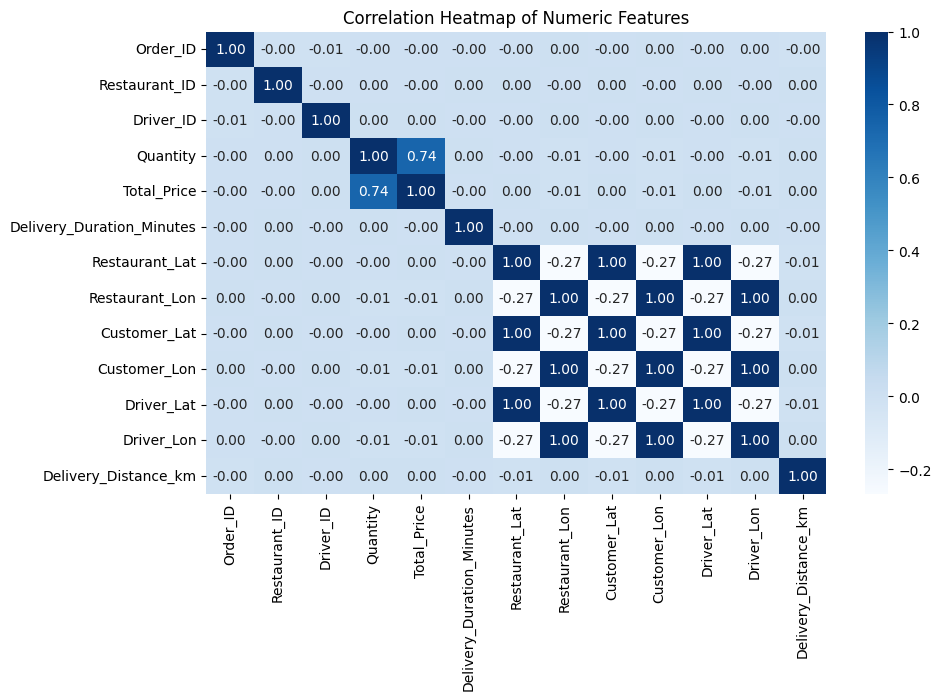

In [14]:
numerical_col = df.select_dtypes(include='number')

corr = numerical_col.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation Heatmap of Numeric Features')
plt.show()


In [15]:
df.drop(columns=['Order_ID','User_ID','Restaurant_ID','Driver_ID'],inplace=True)

In [16]:
df.drop(columns=['Restaurant_Lat','Restaurant_Lon','Customer_Lat','Customer_Lon','Driver_Lat','Driver_Lon','Delivery_Time'],inplace=True)

In [17]:
df.drop(columns = ['Order_Status' , 'Order_Time'],inplace = True)

In [18]:
df.head()

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,Fried Chicken,3,273.72,39,Alexandria,Wallet,Motorbike,1.666106,High,Offline
1,Sandwich,3,365.82,33,Zagazig,Credit Card,Motorbike,2.738698,Low,Online
2,Koshary,3,401.94,38,Assiut,Cash,Car,2.929079,Medium,Online
3,Sushi,2,221.18,52,Mansoura,Cash,Car,0.677498,Low,Online
4,Koshary,5,355.55,44,Mansoura,Wallet,Motorbike,1.994769,High,Online


In [19]:
y = df['Delivery_Duration_Minutes']
X = df.drop(columns='Delivery_Duration_Minutes',axis=1)

In [20]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_col = X.select_dtypes(include = 'number').columns
cat_col = X.select_dtypes(exclude = 'number').columns

num_transformation = Pipeline(steps=[('Imputer' , SimpleImputer(strategy='mean')),
                                     ('Scaling' , StandardScaler())])

cat_transformation = Pipeline(steps=[('Imputer' , SimpleImputer(strategy='most_frequent')),
                                     ('Scaling',OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num' , num_transformation , num_col),
                                               ('cat' , cat_transformation , cat_col)],
                                               remainder = 'drop')

preprocessor


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [21]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print('shape of X_train :',X_train.shape)
print('shape of X_test :',X_test.shape)
print('shape of y_train :',y_train.shape)
print('shape of y_test :',y_test.shape)

shape of X_train : (80001, 9)
shape of X_test : (20001, 9)
shape of y_train : (80001,)
shape of y_test : (20001,)


In [22]:
from sklearn.linear_model import LinearRegression , Lasso,Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'LinearRegression' : LinearRegression(
        fit_intercept=True,
        copy_X=True,
        n_jobs=-1
    ),

    'Lasso' : Lasso(
        alpha=1.0,
        fit_intercept=True,
        selection='random',
        max_iter=1000
    ),

    'Ridge' : Ridge(
        alpha=1.0,
        fit_intercept=True,
        solver='auto',
        max_iter=1000
    )
}

In [23]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import numpy as np

results = {}

for name, model in models.items():
    print(f'Running model: {name}')

    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results[name] = {
        'mean_squared_error': mean_squared_error(y_test, y_pred),
        'root_mean_squared_error': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2_score': r2_score(y_test, y_pred)
    }

# Print neatly
for model_name, metric in results.items():
    print(f'\nModel: {model_name}')
    print('Mean Squared Error:', metric['mean_squared_error'])
    print('Root Mean Squared Error:', metric['root_mean_squared_error'])
    print('R² Score:', metric['r2_score'])


Running model: LinearRegression
Running model: Lasso
Running model: Ridge

Model: LinearRegression
Mean Squared Error: 100.2074367380728
Root Mean Squared Error: 10.010366463725132
R² Score: -0.00011510479477228053

Model: Lasso
Mean Squared Error: 100.19902344928424
Root Mean Squared Error: 10.009946226093536
R² Score: -3.1136404078591084e-05

Model: Ridge
Mean Squared Error: 100.20743400495378
Root Mean Squared Error: 10.010366327210697
R² Score: -0.0001150775170202234


In [24]:
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import pandas as pd

results = {}

for name, model in models.items():
    print(f'Running model : {name}')
    
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    
    # Predictions on train and test
    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)
    
    train_acc = r2_score(y_train, y_pred_train)
    test_acc  = r2_score(y_test, y_pred_test)
    
    results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Generalization Gap': train_acc - test_acc
    }

# Summarize neatly in a DataFrame
results_df = pd.DataFrame(results).T
print("\nTrain vs Test Accuracy Comparison:\n")
print(results_df)


Running model : LinearRegression
Running model : Lasso
Running model : Ridge

Train vs Test Accuracy Comparison:

                  Train Accuracy  Test Accuracy  Generalization Gap
LinearRegression        0.000261      -0.000115            0.000376
Lasso                   0.000000      -0.000031            0.000031
Ridge                   0.000261      -0.000115            0.000376


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


# One-hot encode categorical
X = pd.get_dummies(X, drop_first=True)

# Scale numeric
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [26]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Input(shape=(X_train.shape[1],)),   # define input here
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)   # regression output
])


In [27]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [28]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=7,
                    batch_size=32,
                    verbose=1)


Epoch 1/7
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 164.4703 - mae: 10.1280 - val_loss: 102.7052 - val_mae: 8.4667
Epoch 2/7
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 117.4774 - mae: 8.9697 - val_loss: 101.2886 - val_mae: 8.4130
Epoch 3/7
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 111.1482 - mae: 8.7553 - val_loss: 101.1717 - val_mae: 8.4124
Epoch 4/7
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 106.8873 - mae: 8.6179 - val_loss: 101.8579 - val_mae: 8.4320
Epoch 5/7
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 104.1173 - mae: 8.5216 - val_loss: 100.8416 - val_mae: 8.3976
Epoch 6/7
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 103.0107 - mae: 8.4884 - val_loss: 100.5877 - val_mae: 8.3892
Epoch 7/7
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 102.3983 - mae: 8.4695 - val_loss: 100.4034 - val_mae: 8.3859


In [29]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Mean Absolute Error:", mae)

y_pred = model.predict(X_test)


Mean Absolute Error: 8.385944366455078
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [32]:
df.columns

Index(['Item_Name', 'Quantity', 'Total_Price', 'Delivery_Duration_Minutes',
       'City', 'Payment_Method', 'Driver_Vehicle', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability'],
      dtype='object')

In [51]:
from sklearn.decomposition import PCA

X = df[['Item_Name', 'Quantity', 'Total_Price', 'Delivery_Duration_Minutes','City', 'Payment_Method', 'Driver_Vehicle',
       'Traffic_Level', 'Driver_Availability']]

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ['Quantity','Total_Price','Delivery_Duration_Minutes']
categorical_features = ['City','Payment_Method','Driver_Vehicle','Traffic_Level','Driver_Availability']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])

X_transform = preprocessor.fit_transform(X)


# Step 2: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transform)

print("Explained variance ratio:", (pca.explained_variance_ratio_))

Explained variance ratio: [0.28959353 0.16637076]


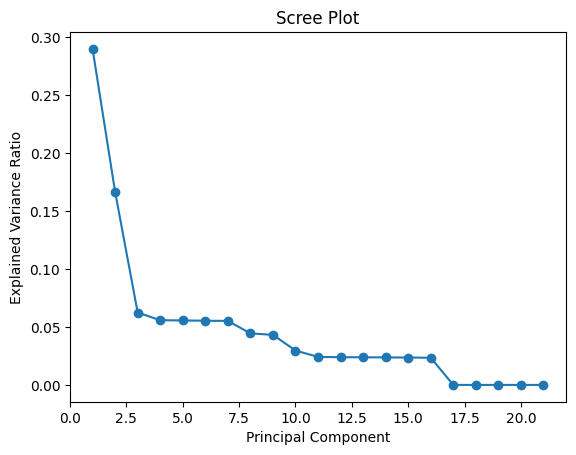

In [47]:
import matplotlib.pyplot as plt

pca_full = PCA().fit(X_transform)

plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1),
         pca_full.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()



In [56]:
import pandas as pd

# Get component loadings
loadings = pd.DataFrame(
    pca.components_, 
    columns=preprocessor.get_feature_names_out()
)

print(loadings)


   num__Quantity  num__Total_Price  num__Delivery_Duration_Minutes  \
0       0.707100          0.707095                        0.000492   
1       0.000961         -0.001636                        0.999958   

   cat__City_Alexandria  cat__City_Assiut  cat__City_Cairo  cat__City_Giza  \
0              0.001300          0.000017        -0.000291       -0.001287   
1             -0.001069          0.001742        -0.001202       -0.001995   

   cat__City_Mansoura  cat__City_Tanta  cat__City_Zagazig  ...  \
0           -0.001057         0.002092          -0.000775  ...   
1            0.000852        -0.000789           0.002461  ...   

   cat__Payment_Method_Credit Card  cat__Payment_Method_Wallet  \
0                         0.000376                    0.000615   
1                         0.001460                   -0.003987   

   cat__Driver_Vehicle_Bicycle  cat__Driver_Vehicle_Car  \
0                     0.002621                -0.002452   
1                     0.000412        

In [60]:
X = df[['Item_Name', 'Quantity', 'Total_Price', 'Delivery_Duration_Minutes','City', 'Payment_Method', 'Driver_Vehicle',
       'Traffic_Level', 'Driver_Availability']]
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ['Quantity','Total_Price','Delivery_Duration_Minutes']
categorical_features = ['City','Payment_Method','Driver_Vehicle','Traffic_Level','Driver_Availability']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])

X_transform = preprocessor.fit_transform(X)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3 , init='k-means++',max_iter=200)
kmeans

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,200
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [63]:
kmeans.fit(X_transform)
X['Cluster'] = kmeans.labels_
X.head()

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Driver_Vehicle,Traffic_Level,Driver_Availability,Cluster
0,Fried Chicken,3,273.72,39,Alexandria,Wallet,Motorbike,High,Offline,0
1,Sandwich,3,365.82,33,Zagazig,Credit Card,Motorbike,Low,Online,2
2,Koshary,3,401.94,38,Assiut,Cash,Car,Medium,Online,1
3,Sushi,2,221.18,52,Mansoura,Cash,Car,Low,Online,0
4,Koshary,5,355.55,44,Mansoura,Wallet,Motorbike,High,Online,1


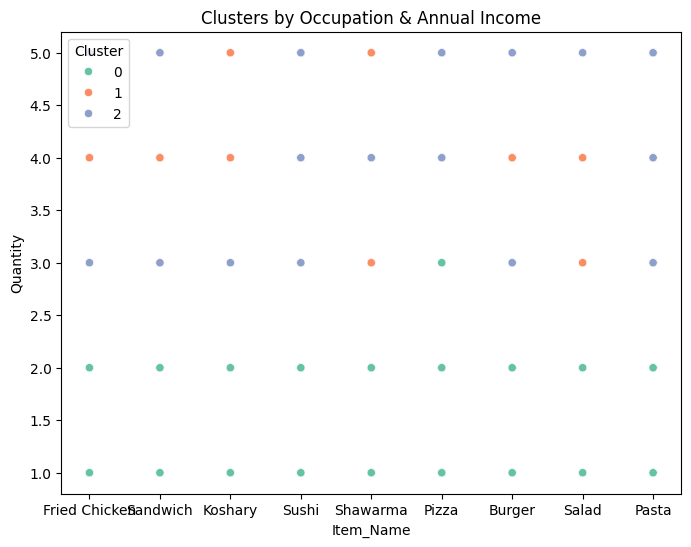

In [64]:
# Step 4: Visualize clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X,
    x='Item_Name',
    y='Quantity',
    hue='Cluster',
    palette='Set2'
)

plt.title("Clusters by Occupation & Annual Income")

plt.show()

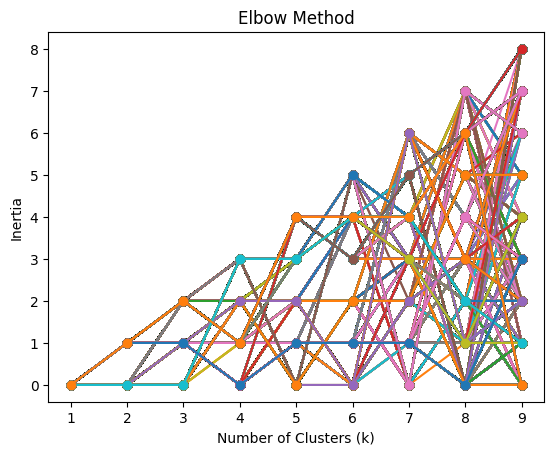

In [67]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k , init='k-means++' , max_iter=1000)
    kmeans.fit(X_transform)
    inertia.append(kmeans.labels_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [76]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans
import numpy as np

sample_size = min(1000,X_transform.shape[0])
sample_idx = np.random.choice(X_transform.shape[0] , sample_size , replace=False)
X_sample = X_transform[sample_idx]

silhouette_scores = {}
inertia = {}

for k in range(2,10):
    model = MiniBatchKMeans(n_clusters=k , init='k-means++' , batch_size=1000 , random_state=42)
    labels = model.fit_predict(X_transform)

    inertia[k] = model.inertia_
    score = silhouette_score(X_sample , labels[sample_idx])
    silhouette_scores[k] = score

    print(f'k : {k} , inertia : {model.inertia_:.0f} , silhouette_score : {score:.2f}')


k : 2 , inertia : 475184 , silhouette_score : 0.18
k : 3 , inertia : 437115 , silhouette_score : 0.14
k : 4 , inertia : 404971 , silhouette_score : 0.10
k : 5 , inertia : 390317 , silhouette_score : 0.10
k : 6 , inertia : 382690 , silhouette_score : 0.08
k : 7 , inertia : 372879 , silhouette_score : 0.07
k : 8 , inertia : 362452 , silhouette_score : 0.07
k : 9 , inertia : 356359 , silhouette_score : 0.07


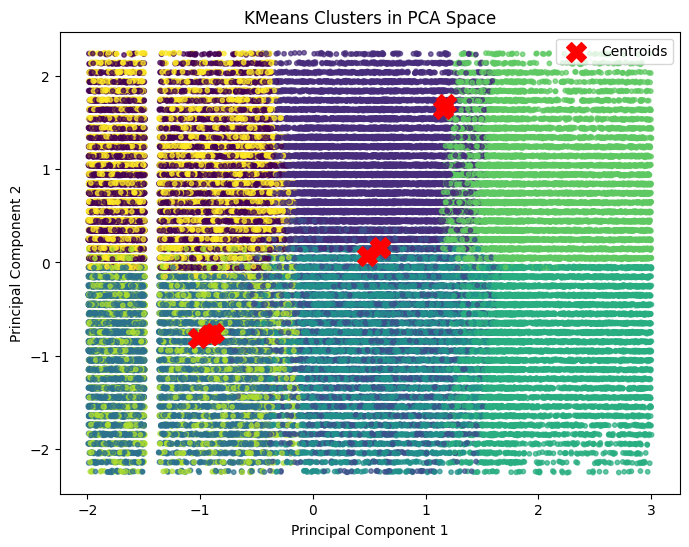

In [77]:
import matplotlib.pyplot as plt

# Assume you already have PCA-transformed data and cluster labels
labels = kmeans.labels_

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], 
            c=labels, cmap='viridis', s=10, alpha=0.7)

# Plot cluster centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            c='red', marker='X', s=200, label='Centroids')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clusters in PCA Space")
plt.legend()
plt.show()
